# Vanishing Gradient Problem
### The problem is that the gradient will be vanishingly small effectively preventing the change in weights. In worst case, stoping the training.

In [17]:
import numpy as np
import pandas as pd

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

import tensorflow as tf
import keras
from keras.models import Sequential 
from keras.layers import Input, Dense

In [2]:
X, y = make_moons(n_samples = 1000, noise = 0.1, random_state = 0)

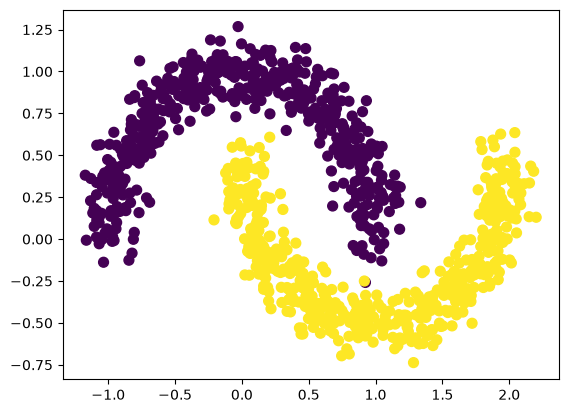

In [4]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c = y, s = 50)
plt.show()

In [ ]:
model = Sequential()

model.add(Dense(10, activation = 'sigmoid', input_dim = 2))
model.add(Dense(10, activation = 'sigmoid'))
model.add(Dense(10, activation = 'sigmoid'))
model.add(Dense(10, activation = 'sigmoid'))
model.add(Dense(10, activation = 'sigmoid'))
model.add(Dense(10, activation = 'sigmoid'))
model.add(Dense(10, activation = 'sigmoid'))
model.add(Dense(10, activation = 'sigmoid'))
model.add(Dense(10, activation = 'sigmoid'))
model.add(Dense(10, activation = 'sigmoid'))
model.add(Dense(10, activation = 'sigmoid'))
model.add(Dense(1, activation = 'sigmoid'))

c:\Users\Keval\OneDrive\Desktop\Deep-Learning-Journey\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(loss = 'binary_crossentropy', optimizer = 'Adam', metrics=['accuracy'])

In [7]:
old_weights = model.get_weights()[0]
old_weights

array([[-0.5122744 , -0.19931448,  0.26572305,  0.303024  ,  0.08812618,
        -0.01996833, -0.36339146, -0.59518313, -0.14289397, -0.6594722 ],
       [ 0.13000953,  0.6969221 , -0.16215795, -0.18893355,  0.2532043 ,
        -0.6341091 , -0.43890414, -0.40367475, -0.64062077,  0.6919604 ]],
      dtype=float32)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [9]:
model.fit(X_train, y_train, epochs = 10)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.5100 - loss: 0.6933
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5100 - loss: 0.6930
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5100 - loss: 0.6935
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5100 - loss: 0.6934
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5100 - loss: 0.6932
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5100 - loss: 0.6938
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5100 - loss: 0.6931
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4775 - loss: 0.6933
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5100 - loss: 0.6937
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5100 - loss: 0.6929


In [12]:
model.optimizer.get_config()['learning_rate']

0.0010000000474974513

In [13]:
new_weights = model.get_weights()[0]

gradient = (old_weights - new_weights) / 0.001

percent_change = abs(100 * (old_weights - new_weights) / old_weights) 

print(f"Gradient :\n {gradient}")
print(f"\n Change In Weights(%) :\n {percent_change}")

Gradient :
 [[-11.065005     0.98797673  -3.188729    -0.9516179    2.8173623
  -11.121332     2.1573305   -3.5946367   -0.8796304   -1.1027455 ]
 [ 10.0597515   -0.9006261    2.5310366    0.8441954   -2.2782981
    8.538365    -1.6782283    3.2088158    0.72264665   0.9453892 ]]

 Change In Weights(%) :
 [[ 2.1599765   0.49568743  1.2000198   0.31404045  3.1969643  55.694855
   0.5936657   0.6039548   0.61558264  0.16721638]
 [ 7.737703    0.1292291   1.5608464   0.44682136  0.89978653  1.3465136
   0.38236788  0.7949014   0.11280414  0.13662477]]


### Most of them are not change Even 1% so we can say that we have Vanishing Gradient Problem.

# Handling Vanishing Gradient Problem

### 1. Reduce model complexity

In [19]:
model = Sequential()

model.add(Input(shape = (2,)))
model.add(Dense(10, activation = 'sigmoid'))
model.add(Dense(10, activation = 'sigmoid'))
model.add(Dense(10, activation = 'sigmoid'))
model.add(Dense(1, activation = 'sigmoid'))

model.compile(loss = 'binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

old_weights = model.get_weights()[0]

model.fit(X_train, y_train,epochs = 10)

new_weights = model.get_weights()[0]

gradient = (old_weights - new_weights) / 0.001

percent_change = abs(100 * (old_weights - new_weights) / old_weights) 

print(f"Gradient :\n {gradient}")
print(f"\n Change In Weights(%) :\n {percent_change}")

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4900 - loss: 0.7159
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4900 - loss: 0.7011
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4900 - loss: 0.6960
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4712 - loss: 0.6940
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5100 - loss: 0.6928
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5100 - loss: 0.6925
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5100 - loss: 0.6904
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6895
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7575 - loss: 0.6882
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5913 - loss: 0.6864
Gradient :
 [[-108.01494   -94.40249  -282.62454   243.67343   180.98628  -246.12994
  -293.8504   -234.97816  -176.29591   226.27638 ]
 [ 125.130585   93.8782

### Now we can see that we have more channge in the Weights than before and also we have very large values for Gradients.

---

---

### 2. Use different Activation Functions

___

In [20]:
model = Sequential()

model.add(Input(shape = (2,)))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

model.compile(loss = 'binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

old_weights = model.get_weights()[0]

model.fit(X_train, y_train,epochs = 10)

new_weights = model.get_weights()[0]

gradient = (old_weights - new_weights) / 0.001

percent_change = abs(100 * (old_weights - new_weights) / old_weights) 

print(f"Gradient :\n {gradient}")
print(f"\n Change In Weights(%) :\n {percent_change}")

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6963 - loss: 0.6876
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8425 - loss: 0.6479
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8650 - loss: 0.5541
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9013 - loss: 0.4714
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9312 - loss: 0.4127
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9463 - loss: 0.3640
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9563 - loss: 0.2960
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9563 - loss: 0.2085
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9638 - loss: 0.1267
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9750 - loss: 0.0872
Gradient :
 [[  34.425526  154.15775   -96.92677   -46.531376  125.20539   -46.31811
    83.452934  -35.664406  -70.748924   94.327324]
 [ -82.79356  -132.910

### As we can see the by using ReLu activation the Gradient didn't vanish